In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('Churn_customer.csv')

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Replacing blanks with 0 as tenure is 0 and no total charges are recorded

In [6]:
df['TotalCharges'] = df['TotalCharges'].replace(' ','0').astype('float')

In [8]:
df.isna().sum().sum()

np.int64(0)

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


### Converting 0 and 1 values to Yes and No in SeniorCitzen column

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['customerID'].duplicated().sum()

np.int64(0)

In [12]:
df['SeniorCitizen']

,SeniorCitizen
0,0
1,0
2,0
3,0
4,0
...,...
7038,0
7039,0
7040,0
7041,1


In [13]:
def conv(value):
  if value == 1:
    return "Yes"
  else:
    return 'No'

df['SeniorCitizen'] = df['SeniorCitizen'].apply(conv)

In [14]:
df.sample(6)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2698,8150-QUDFX,Male,No,No,No,2,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.85,51.60,No
6152,7562-GSUHK,Female,No,No,No,16,Yes,No,Fiber optic,No,...,Yes,No,No,Yes,Month-to-month,Yes,Credit card (automatic),93.20,1573.70,Yes
4569,7639-SUPCW,Female,No,No,No,22,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),48.80,1054.60,Yes
934,4198-VFOEA,Female,No,No,No,12,No,No phone service,DSL,Yes,...,No,Yes,No,No,One year,Yes,Mailed check,33.60,435.45,No
4902,5092-STPKP,Female,No,No,No,24,Yes,No,DSL,Yes,...,No,Yes,No,No,Month-to-month,No,Credit card (automatic),56.35,1381.20,No
344,5924-SNGKP,Female,No,No,Yes,41,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Credit card (automatic),20.25,865.00,No


### Understanding How many cutomers Churned out?

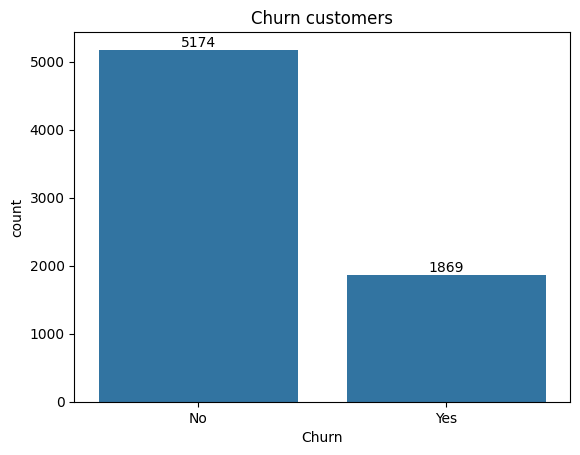

In [15]:
ax = sns.countplot(x = 'Churn', data=df )

ax.bar_label(ax.containers[0])
plt.title("Churn customers")
plt.show()

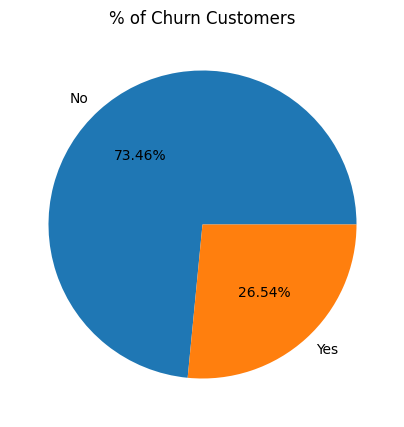

In [16]:
# Seeing the same values in percentages

plt.figure(figsize=(5,5))
gb = df.groupby('Churn').agg({'Churn':'count'})
gb
plt.pie(gb['Churn'], labels = gb.index, autopct = '%1.2f%%')
plt.title("% of Churn Customers")
plt.show()

### Exploring the reason Why the customers Churned out

Text(0.5, 1.0, 'Churn By Gender')

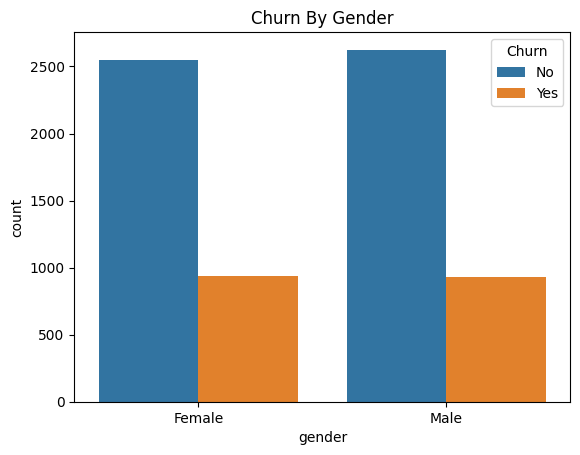

In [17]:
sns.countplot(x='gender', data=df, hue='Churn')
plt.title('Churn By Gender')

Text(0.5, 1.0, 'Churn By SeniorCitizen')

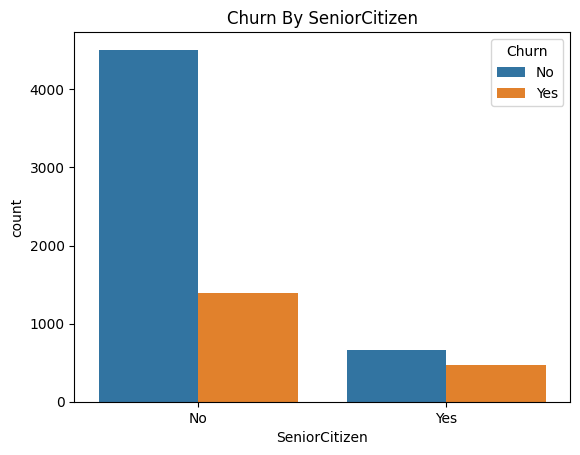

In [18]:
sns.countplot(x='SeniorCitizen', data=df, hue='Churn')
plt.title('Churn By SeniorCitizen')

<Figure size 1800x1800 with 0 Axes>

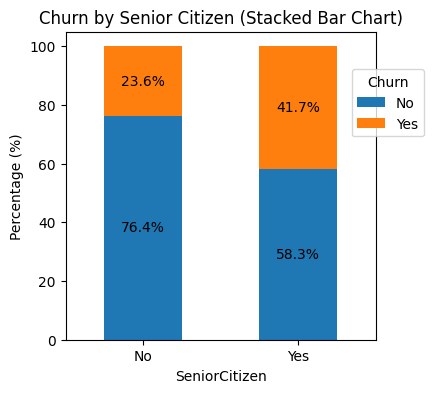

In [19]:
plt.figure(figsize=(18,18))

total_counts = df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack() * 100

# Plot
fig, ax = plt.subplots(figsize=(4, 4))

total_counts.plot(kind='bar', stacked=True, ax=ax, color=['#1f77b4', '#ff7f0e'])

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, y + height / 2, f'{height:.1f}%', ha='center', va='center')

plt.title('Churn by Senior Citizen (Stacked Bar Chart)')
plt.xlabel('SeniorCitizen')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Churn', bbox_to_anchor = (0.9,0.9))

plt.show()

Comparatively a great % of people in SeniorCitizen category have churned

###

In [20]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [21]:
df['tenure'].nunique()

73

<Axes: xlabel='tenure', ylabel='Count'>

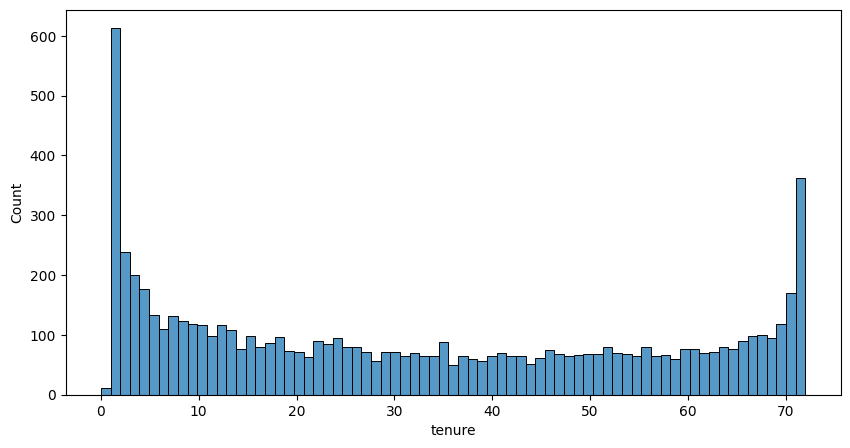

In [22]:
plt.figure(figsize=(10,5))
sns.histplot(x = 'tenure', data = df, bins=73)

<Axes: xlabel='tenure', ylabel='Count'>

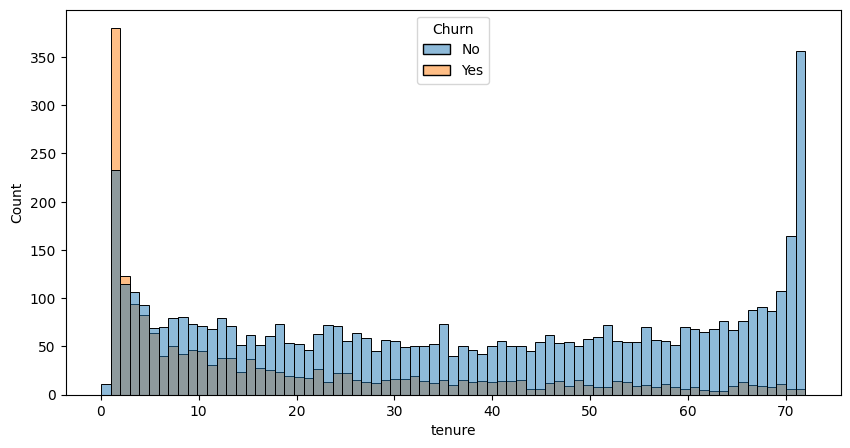

In [23]:
plt.figure(figsize=(10,5))
sns.histplot(x = 'tenure', data = df, bins=73, hue='Churn')

People who have used our services for a long time have stayed and people who have used our services 1 or 2 months have Churned

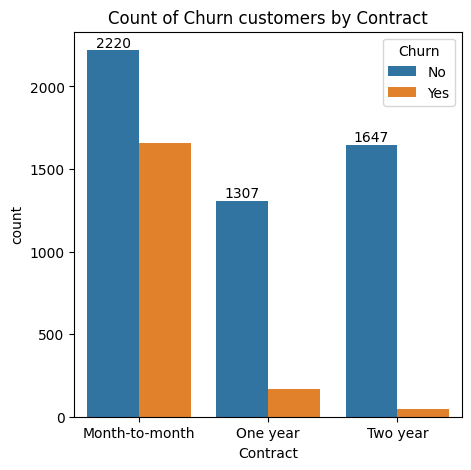

In [24]:
plt.figure(figsize=(5,5))
ax = sns.countplot(x = 'Contract', data=df , hue='Churn')

ax.bar_label(ax.containers[0])
plt.title("Count of Churn customers by Contract")
plt.show()

People who have Month-to-Month contract have likely to churn than from those who have 1 or 2 years of Contract

In [25]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

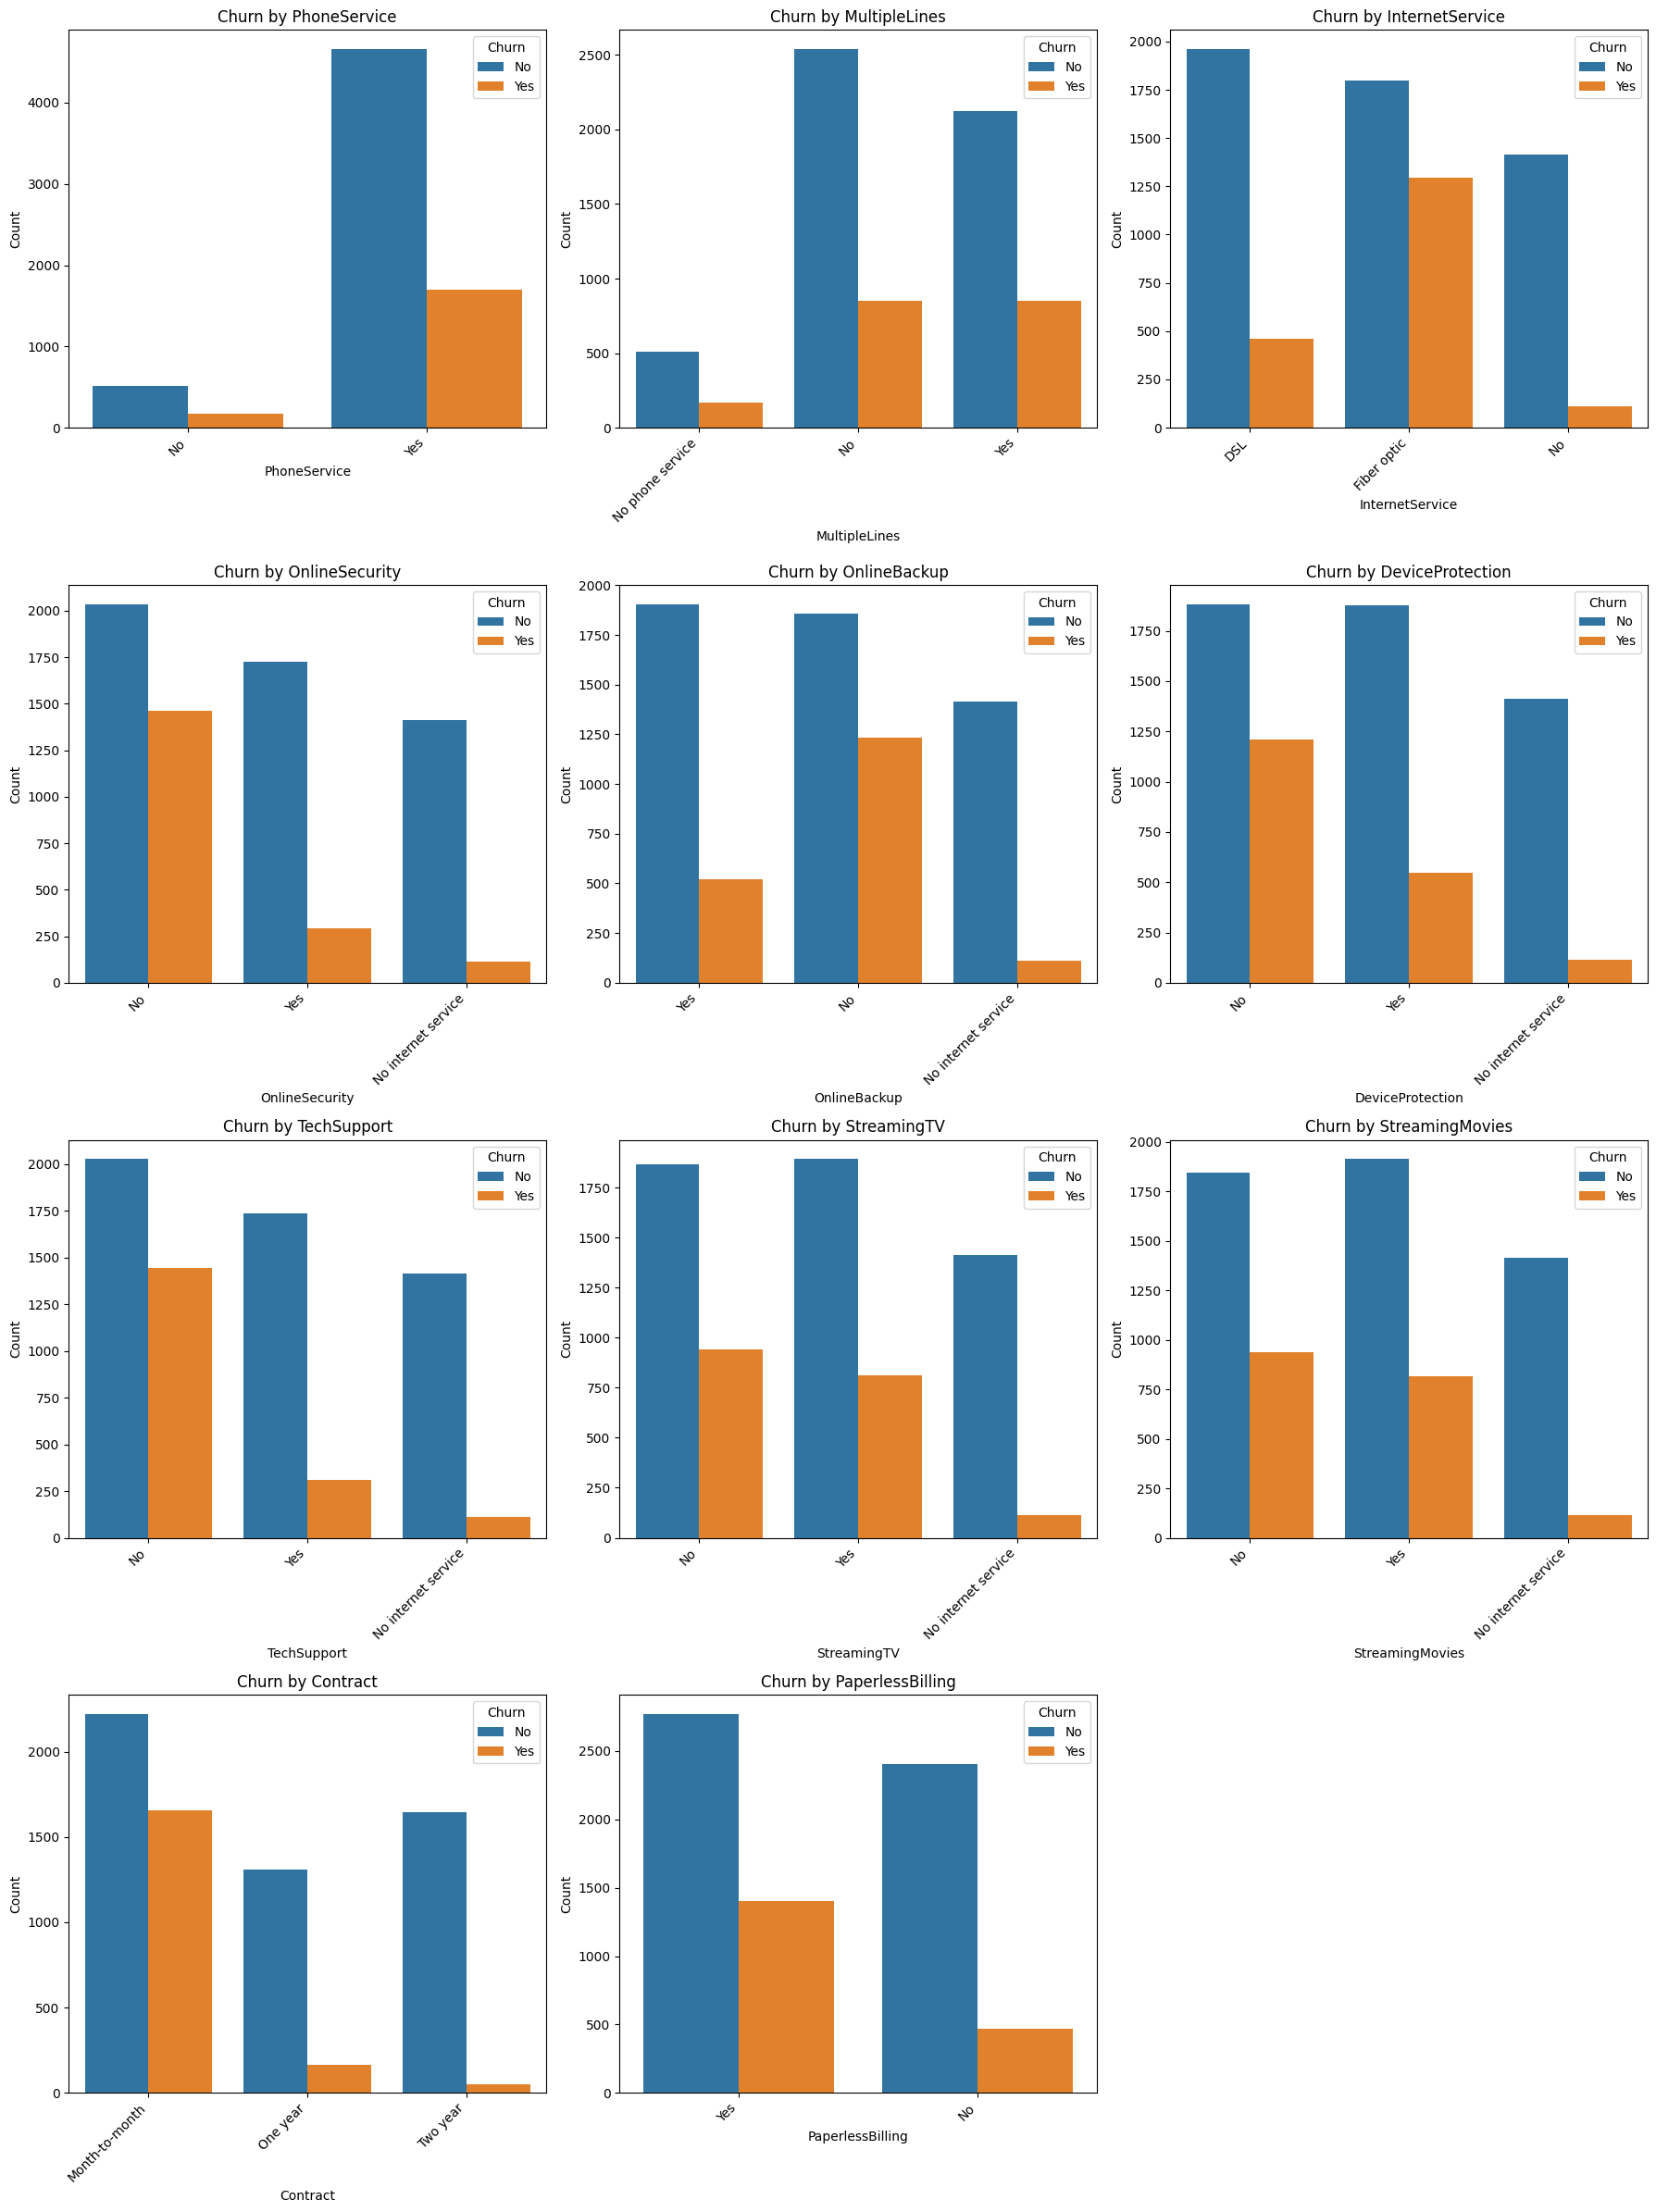

In [26]:
columns_to_plot = ['PhoneService', 'MultipleLines', 'InternetService',
                       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling']

num_columns = len(columns_to_plot)
num_rows = (num_columns + 2) // 3

plt.figure(figsize=(18, num_rows * 6))

for i, column in enumerate(columns_to_plot):
    plt.subplot(num_rows, 3, i + 1)
    sns.countplot(x=column, data=df, hue='Churn')
    plt.title(f'Churn by {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')

plt.tight_layout() # To prevent overlapping
plt.show()

The majority of customers who no not churn tend to have services like honeService, InternetService, and OnlineSecurity enabled. For services like OnlineBackup, TechSupport and StreamingTV, churn rates are noticeably

Text(0.5, 1.0, 'Churn By Payment Method')

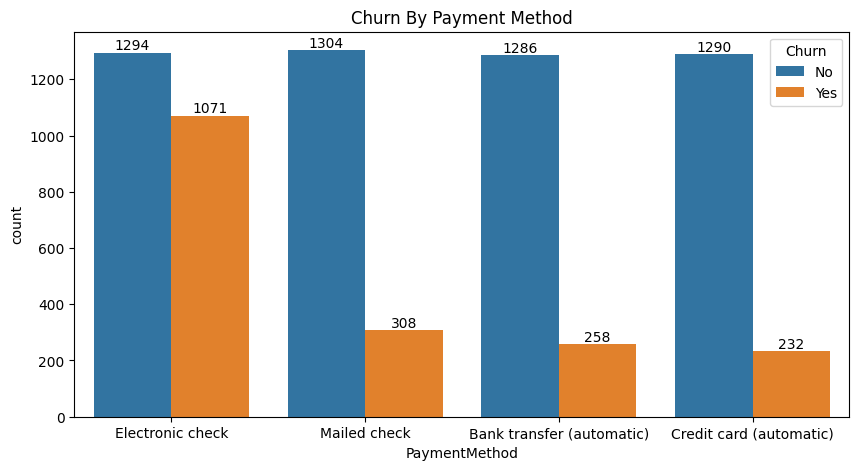

In [27]:
plt.figure(figsize=(10,5))
ax = sns.countplot(x='PaymentMethod', data=df, hue='Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Churn By Payment Method')

from types import MethodDescriptorType
Customer is likely to churn when he is using electronic check as the payment method

And people who have auto pay ON are likely not to churn

# Valuable Insights:


*   Customers who stayed with the company for a long time were much less likely to churn, while customers with only 1–2 months of tenure showed the highest churn rate.
*   Customers using month-to-month contracts churned significantly more than customers with yearly or two-year contracts.
* Senior citizens showed a higher tendency to churn compared to younger customers, indicating possible dissatisfaction or usability issues
* Customers enrolled in automatic payment methods and long-term contracts were more loyal


